# Market-Neutral Trading Algorithm
**Joel Cerraga · Milestone 1: research foundations**

This notebook follows the SPX project workflow: understand the method, check it on controlled inputs, then move to market data. It reuses the Python modules in this package.

**Every price and performance result below is synthetic.** The generator deliberately includes mean reversion. These results check mechanics and do not establish market profitability. Historical evaluation and persistent homology are later milestones.

## 1. Objective
Can a stock’s recent movement relative to connected stocks produce a useful reversal signal after dollar exposure, market beta and trading costs are accounted for? The first task is to build a calculation we can explain and test.

> Current project status after Milestone 5: the 2020–2025 reserved test has now been evaluated. This notebook retains its earlier milestone calculations and information state; see `05-final-evaluation.ipynb` for the final findings.


In [1]:
from pathlib import Path
import sys
from dataclasses import asdict
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if not (ROOT / "run_research.py").exists():
    ROOT = ROOT.parent
if not (ROOT / "run_research.py").exists():
    raise RuntimeError("Open this notebook from the project root or notebooks folder")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from market_neutral.config import ResearchConfig
from market_neutral.data import simple_returns
from run_research import run
config = ResearchConfig()
print("Project:", ROOT.name)
print("SYNTHETIC VALIDATION — not historical performance")

Project: Market-Neutral-Trading-Algorithm
SYNTHETIC VALIDATION — not historical performance


## 2. Fix the experiment before inspecting results
The defaults are transparent engineering assumptions, not optimised parameters. A gross limit of 1.0 means up to 50% long plus 50% short when dollar neutral. The 8% name limit can reduce gross utilisation.

The 5 bps fee applies to every dollar traded. Borrow is 2% per year on short notional, using calendar days. Neither number is a broker quote.

In [2]:
display(pd.Series(asdict(config), name="Value").to_frame())

,Value
seed,42.00
observations,756.00
assets,36.00
sectors,6.00
correlation_window,126.00
beta_window,126.00
volatility_window,63.00
signal_window,5.00
neighbours,5.00
minimum_correlation,0.20


## 3. Run the shared research pipeline
The same function generates the data, computes the decisions, simulates execution and writes the results. This avoids maintaining a separate notebook backtest.

There are 36 artificial stocks and six sector factors. A latent mean-reverting component is included intentionally; it favours a reversal hypothesis and must not be mistaken for market evidence.

In [3]:
output = ROOT / "outputs" / "synthetic"
dataset, decisions, results, summary = run(config=config, output=output)
returns, market = simple_returns(dataset)
print(dataset.metadata["data_kind"])
print(f"{dataset.prices.shape[1]} assets; {len(returns)} daily return observations")
print(dataset.metadata["warning"])
display(dataset.prices.iloc[:5, :6].round(3))

SYNTHETIC — NOT HISTORICAL MARKET DATA
36 assets; 756 daily return observations
Fixture design favours reversal hypotheses. Performance is not evidence of tradable alpha.


,SYN01,SYN02,SYN03,SYN04,SYN05,SYN06
date,,,,,,
2020-01-02,100.000,100.000,100.000,100.000,100.000,100.000
2020-01-03,99.547,102.681,100.317,101.083,100.024,100.967
2020-01-06,99.934,103.543,99.934,100.110,99.787,101.380
2020-01-07,99.247,105.377,100.836,101.914,100.072,104.393
2020-01-08,99.547,106.642,100.377,102.051,100.639,105.568


## 4. From price movement to graph signal

The baseline reverses a volatility-scaled recent movement, \(s^{base}=-x\). The graph model first smooths that movement across connected stocks:

\[
\widetilde{x}=e^{-\tau L}x,\qquad s^{graph}=-(x-\widetilde{x}).
\]

Here \(L=(D-W)/\bar d\) is a scaled combinatorial graph Laplacian. Positive rolling correlations determine edge weights. The algorithm retains the union of the five-nearest-neighbour choices above a correlation of 0.20. Negative correlations are omitted in this first model.

A stock with a larger recent rise than its smoothed graph value receives a negative raw score. It is not yet a portfolio weight: dollar and beta constraints come next. As Chung (1997) explains in *Spectral Graph Theory*, Laplacian spectra describe graph structure. Kondor and Lafferty (2002), in *Diffusion Kernels on Graphs and Other Discrete Input Spaces*, supply the heat-kernel smoothing context. Trading the residual remains this project’s hypothesis.

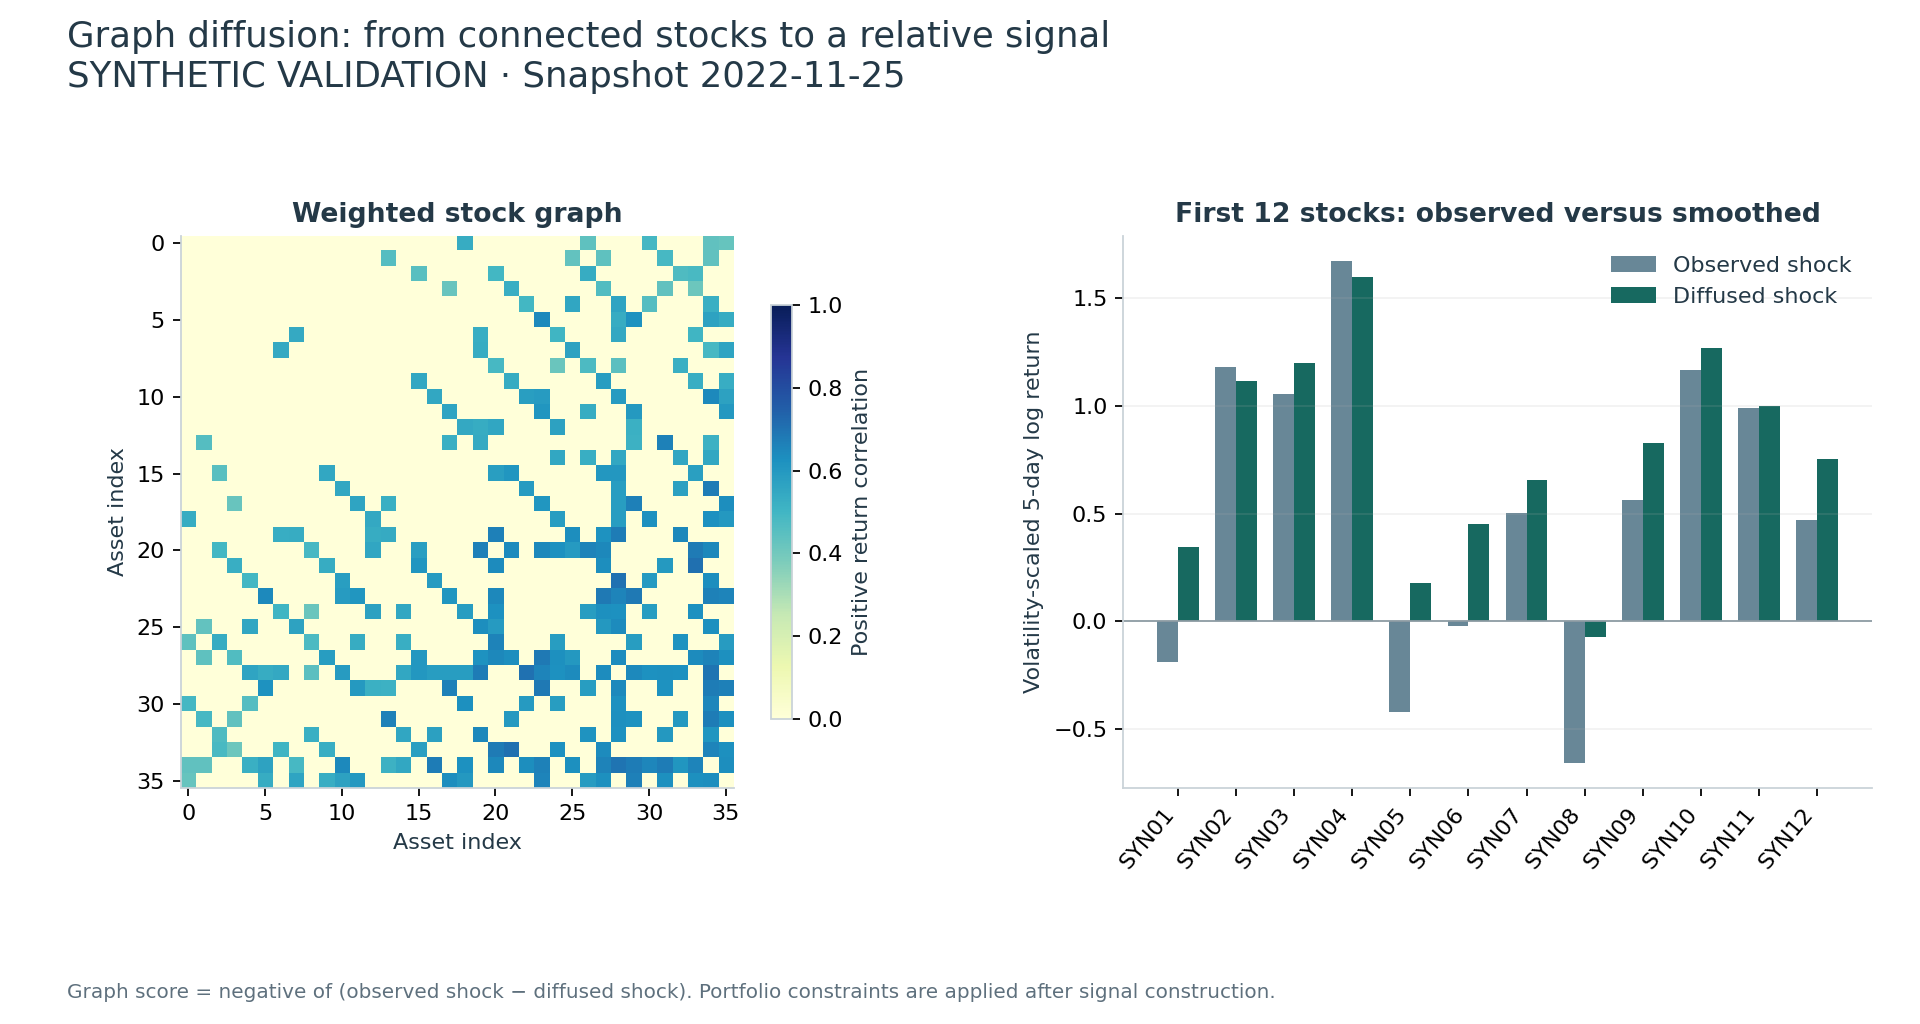

,mean_correlation,edges,isolated_assets,diffusion_residual_norm
date,,,,
2022-11-21,0.4569,146,0,2.0818
2022-11-22,0.4573,149,0,2.0497
2022-11-23,0.4602,151,0,1.8661
2022-11-24,0.4655,149,0,2.1584
2022-11-25,0.4602,148,0,2.1244


In [4]:
display(Image(filename=str(output / "02-graph-diffusion.png")))
display(decisions.diagnostics.tail().round(4))

## 5. Define market-neutral operationally
The portfolio construction removes the components of each score associated with the all-ones vector and the trailing beta vector. It then scales all positions together to respect exposure caps. As Golub and Van Loan (2013) discuss in *Matrix Computations*, least squares supplies the numerical projection framework.

\[
\mathbf{1}^{T}w\approx0,\qquad\hat\beta^{T}w\approx0.
\]

These are constraints against the most recently available estimate. They do not guarantee zero future beta or zero sector exposure. All metrics below refer to a rebalance, after fees.

In [5]:
exposure_columns = ["max_abs_net_exposure", "max_abs_estimated_beta", "max_gross_exposure", "max_position"]
with pd.option_context("display.float_format", "{:.3e}".format):
    display(summary[exposure_columns])
assert summary["max_abs_net_exposure"].max() < 1e-10
assert summary["max_abs_estimated_beta"].max() < 1e-10
assert summary["max_gross_exposure"].max() <= config.gross_limit + 1e-10
assert summary["max_position"].max() <= config.position_limit + 1e-10
print("Exposure checks passed.")

Exposure checks passed.


,max_abs_net_exposure,max_abs_estimated_beta,max_gross_exposure,max_position
strategy,,,,
baseline,3.525e-15,3.691e-15,1.000e+00,8.000e-02
graph,1.291e-15,1.457e-15,1.000e+00,8.000e-02


## 6. Prevent a signal from earning returns before execution

| Event | Time |
| --- | --- |
| Observe data and calculate a decision | Close t |
| Execute that decision | Close t+1 |
| First holding-period return from the new position | Close t+2 |

The ledger marks old positions before trading. It charges for trades needed to correct drift, even if the target weight has not changed. It includes entry and final liquidation costs.

The rows below show the initial execution followed by the first possible return. The first entry can have a net loss from trading costs while its gross return is zero.

In [6]:
first = config.warmup
columns = ["gross_return", "net_return", "trading_cost", "borrow_cost", "gross_exposure", "estimated_beta_exposure"]
display(results["graph"].ledger.iloc[first-1:first+3][columns])

,gross_return,net_return,trading_cost,borrow_cost,gross_exposure,estimated_beta_exposure
date,,,,,,
2020-06-26,0.000000,0.000000,0.000000,0.000000,0.0,0.000000e+00
2020-06-29,0.000000,-0.000500,49.975012,0.000000,1.0,-6.938894e-17
2020-06-30,0.002398,0.002046,32.421723,2.738357,1.0,-7.077672e-16
2020-07-01,0.002854,0.002519,30.762097,2.743959,1.0,-6.106227e-16


## 7. Inspect simulated performance and realised beta
The results are descriptive diagnostics. The evaluation excludes the common estimation warm-up and includes all trading and liquidation fees. The generator’s reversal structure prevents us from treating a good result as evidence for the financial hypothesis.

The lower-right chart estimates realised beta from a rolling 63-observation window. It can differ from zero even when estimated beta at each rebalance is neutral.

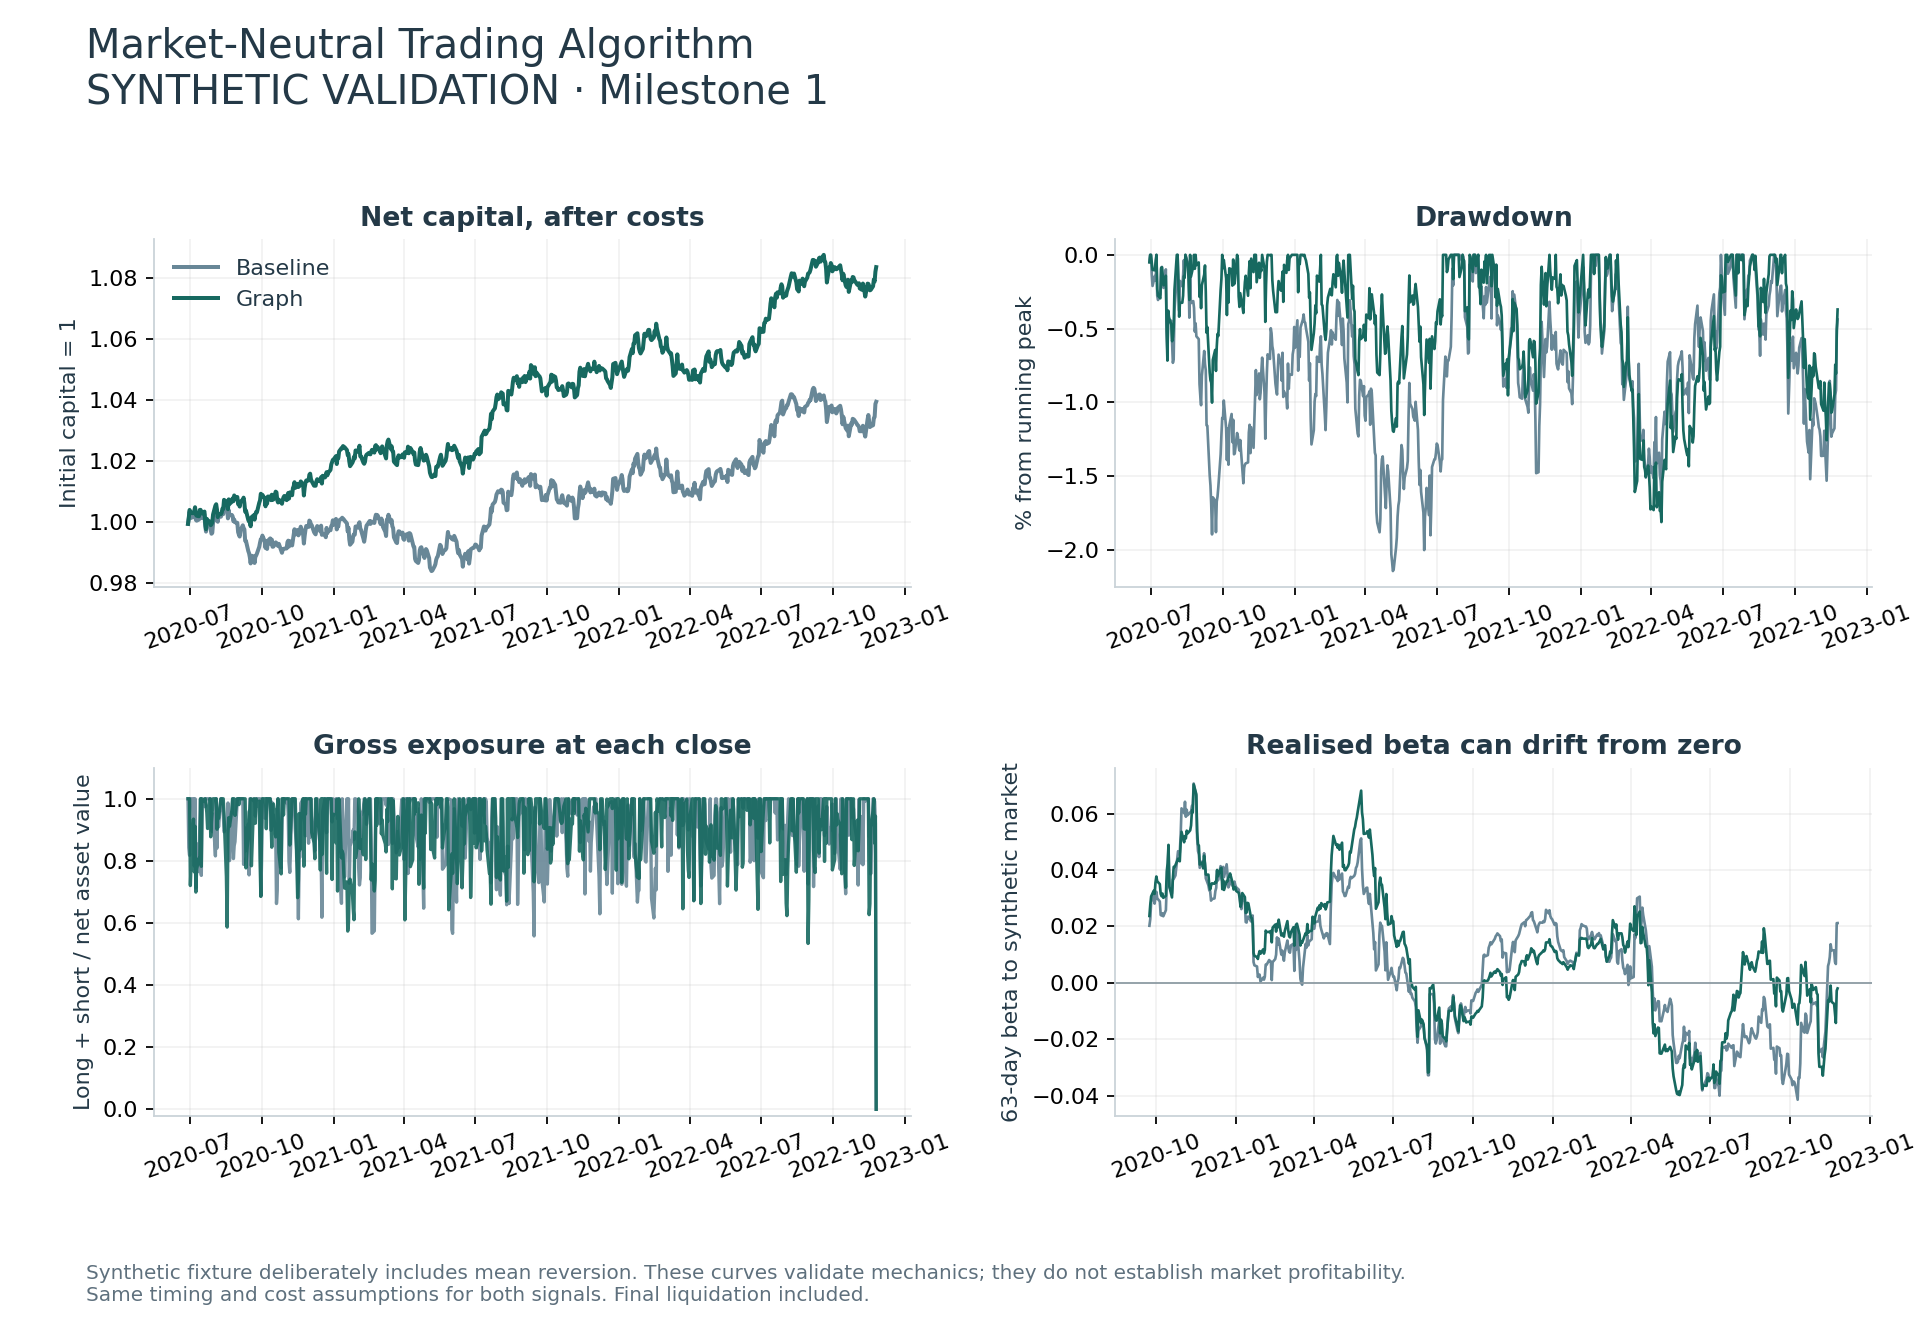

# Market-Neutral Trading Algorithm

## Milestone 1: validation results

**Data: SYNTHETIC — NOT HISTORICAL MARKET DATA.**

This run checks the research implementation. It is not an out-of-sample market study. The synthetic generator deliberately includes mean reversion, so favourable results cannot establish an investment edge.

| Measure | Baseline reversal | Graph diffusion |
| --- | ---: | ---: |
| Simulated total return | 3.96% | 8.37% |
| Simulated Sharpe (zero cash rate) | 0.58 | 1.27 |
| Simulated maximum drawdown | -2.14% | -1.81% |
| Realised market beta | 0.0103 | 0.0082 |
| Mean daily traded notional / start NAV | 61.73% | 62.48% |
| Trading costs, capital units | 19,622.24 | 20,460.98 |
| Borrow costs, capital units | 2,222.04 | 2,293.48 |
| Largest absolute net dollar exposure | 3.52e-15 | 1.29e-15 |
| Largest absolute estimated beta exposure | 3.69e-15 | 1.46e-15 |
| Largest gross exposure | 100.00% | 100.00% |
| Largest single position | 8.00% | 8.00% |

## Interpretation

Neutrality holds against the lagged beta estimate at each rebalance. It does not imply zero future market covariance, sector exposure, intraday exposure or drawdown. Performance metrics exclude the common estimation warm-up and include entry and terminal liquidation costs.

Assumptions: 5 bps per dollar bought or sold; 2% annual borrow on short notional, ACT/365; 100% gross limit; 8% name limit. Cash interest and financing rebates are zero. Fee settings are examples, not broker quotes.

## Next research gate

Choose and document a historical data source, point-in-time universe, adjustment convention, calendar and liquidity rules. Freeze a chronological evaluation plan before inspecting results. Only then compare the two signals on market data and add persistent-homology regime features.


In [7]:
display(Image(filename=str(output / "01-performance-and-exposures.png")))
display(Markdown((output / "milestone-1-results.md").read_text(encoding="utf-8")))

## 8. Run independent checks
The checks include a hand-calculated timing example, entry and exit fees, price-drift turnover, weekend borrowing and changes to future observations. They check the engine, not whether the financial strategy is profitable.

In [8]:
import subprocess
validation = ROOT / "validation"
validation.mkdir(exist_ok=True)
checked = subprocess.run([sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"], cwd=ROOT, capture_output=True, text=True)
log = checked.stdout + checked.stderr
(validation / "unittest.txt").write_text(log, encoding="utf-8")
print(log)
assert checked.returncode == 0, "Research checks failed"

test_borrow_accrues_over_calendar_weekend (test_research.ResearchChecks.test_borrow_accrues_over_calendar_weekend) ... ok
test_constant_signal_is_preserved_and_heat_matches_expm (test_research.ResearchChecks.test_constant_signal_is_preserved_and_heat_matches_expm) ... ok
test_decision_cannot_earn_same_or_next_close_return (test_research.ResearchChecks.test_decision_cannot_earn_same_or_next_close_return) ... ok
test_disconnected_graph_produces_no_diffusion_residual (test_research.ResearchChecks.test_disconnected_graph_produces_no_diffusion_residual) ... ok
test_entry_and_liquidation_fee_match_closed_form (test_research.ResearchChecks.test_entry_and_liquidation_fee_match_closed_form) ... ok
test_full_run_accounting_and_neutrality (test_research.ResearchChecks.test_full_run_accounting_and_neutrality) ... ok
test_future_prices_cannot_change_past_decisions (test_research.ResearchChecks.test_future_prices_cannot_change_past_decisions) ... ok
test_graph_energy_cannot_increase_under_diffusion 

## 9. Next research decision
The next milestone selects and documents historical data, freezes a chronological evaluation protocol and runs the baseline first. The graph signal then receives the same cost and exposure treatment. Persistent-homology features come after that comparison, with simpler correlation and volatility features as controls.

At the original Milestone 1 release, H0/H1 extraction was not implemented. It is now completed in `04-topology-features.ipynb`, using the interface described by Tralie et al. (2018) in *Ripser.py: A lean persistent homology library for Python*. This notebook retains the synthetic experiment’s scope.

Read `docs/methodology.md` for the equations and `docs/research-plan.md` for completion gates. These synthetic outputs justify an engineering claim only. As Lo and MacKinlay (1990) explain in *When Are Contrarian Profits Due to Stock Market Overreaction?*, contrarian returns do not establish a unique overreaction mechanism.

## Problem-solving record

Read `docs/milestone-decisions.md` for this milestone’s setbacks, design forks, responses and unresolved limitations. These entries are based on retained evidence; negative financial findings are not described as fixed.

## References

Chung, F.R.K. (1997) *Spectral Graph Theory*. CBMS Regional Conference Series in Mathematics, 92. American Mathematical Society. doi: [10.1090/cbms/092](https://doi.org/10.1090/cbms/092).

Golub, G.H. and Van Loan, C.F. (2013) *Matrix Computations*. 4th edn. Johns Hopkins University Press. doi: [10.56021/9781421407944](https://doi.org/10.56021/9781421407944).

Kondor, R.I. and Lafferty, J.D. (2002) ‘Diffusion Kernels on Graphs and Other Discrete Input Spaces’, in *Proceedings of the 19th International Conference on Machine Learning*, pp. 315–322. doi: [10.5555/645531.655996](https://doi.org/10.5555/645531.655996).

Lo, A.W. and MacKinlay, A.C. (1990) ‘When Are Contrarian Profits Due to Stock Market Overreaction?’, *The Review of Financial Studies*, 3(2), pp. 175–205. doi: [10.1093/rfs/3.2.175](https://doi.org/10.1093/rfs/3.2.175).

Tralie, C., Saul, N. and Bar-On, R. (2018) ‘Ripser.py: A lean persistent homology library for Python’, *Journal of Open Source Software*, 3(29), p. 925. doi: [10.21105/joss.00925](https://doi.org/10.21105/joss.00925).